# **Day 66: Recurrent Neural Networks - RNN, LSTM and GRU**
*Module 10 - Deep Learning Foundations*

Many data are **sequences**: text, speech, sensor streams, river flow, and **satellite image time series** (the NDVI profile of a field over a season tells us which crop it is). Recurrent networks process a sequence step by step, carrying a **hidden state** that summarises the past.

> Recurrent networks read sequences one step at a time and keep a memory of what they have seen. LSTMs and GRUs are improved versions that remember longer, which makes them suitable for time series and text.
>
> *Example:* An LSTM reading a crop's NDVI series month by month can remember the early-season flooding that identifies paddy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, time, copy
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(66); rng = np.random.default_rng(66)

## **1. The Vanilla RNN**
At each time step: $\mathbf h_t = \tanh(W_{xh}\mathbf x_t + W_{hh}\mathbf h_{t-1} + \mathbf b)$. The same weights are used at every step (weight sharing over time). The final $\mathbf h_T$ (or all $\mathbf h_t$) feed an output layer.

In [2]:
class RNNScratch(nn.Module):
    def __init__(self, n_in, n_hidden):
        super().__init__(); self.Wx = nn.Linear(n_in, n_hidden); self.Wh = nn.Linear(n_hidden, n_hidden, bias=False); self.n_hidden = n_hidden
    def forward(self, x):                                   # x: (batch, time, features)
        h = torch.zeros(x.shape[0], self.n_hidden); hs = []
        for t in range(x.shape[1]):
            h = torch.tanh(self.Wx(x[:, t]) + self.Wh(h)); hs.append(h)
        return torch.stack(hs, 1), h

mine = RNNScratch(3, 8); ref = nn.RNN(3, 8, batch_first=True)
with torch.no_grad():                                        # copy weights to compare with PyTorch's implementation
    ref.weight_ih_l0.copy_(mine.Wx.weight); ref.bias_ih_l0.copy_(mine.Wx.bias); ref.weight_hh_l0.copy_(mine.Wh.weight); ref.bias_hh_l0.zero_()
xs = torch.randn(2, 5, 3)
print("scratch RNN == nn.RNN:", torch.allclose(mine(xs)[0], ref(xs)[0], atol=1e-6))

scratch RNN == nn.RNN: True


## **2. Vanishing Gradients Over Time**
BPTT multiplies the gradient by $W_{hh}^\top\text{diag}(\tanh')$ at every step back in time. Over many steps it shrinks (or explodes) exponentially, so a vanilla RNN struggles to learn **long-range dependencies**. Test: the label depends only on the **first** value of a long sequence.

In [3]:
def memory_task(n, T, r):
    x = r.normal(0, 1, (n, T, 1)).astype(np.float32); y = (x[:, 0, 0] > 0).astype(np.int64); return x, y

class SeqClassifier(nn.Module):
    def __init__(self, cell="lstm", n_in=1, n_hidden=32, n_out=2):
        super().__init__()
        self.rnn = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell](n_in, n_hidden, batch_first=True); self.out = nn.Linear(n_hidden, n_out)
    def forward(self, x):
        o, _ = self.rnn(x); return self.out(o[:, -1])

def train_seq(model, X, y, Xv, yv, epochs=30, lr=3e-3, clip=1.0, bs=64):
    dl = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y)), batch_size=bs, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad(); F.cross_entropy(model(xb), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip); opt.step()
    model.eval()
    with torch.no_grad(): return (model(torch.tensor(Xv)).argmax(1).numpy() == yv).mean()

rows = {}
for T in [5, 20, 60]:
    X_, y_ = memory_task(2000, T, rng); Xv_, yv_ = memory_task(500, T, rng)
    rows[T] = {cell: train_seq(SeqClassifier(cell), X_, y_, Xv_, yv_, epochs=15) for cell in ["rnn", "gru", "lstm"]}
pd.DataFrame(rows).T.rename_axis("sequence length").round(3)

,rnn,gru,lstm
sequence length,,,
5,0.994,0.998,0.988
20,0.970,0.996,0.830
60,0.532,0.498,0.506


## **3. LSTM and GRU**
The **LSTM** (Hochreiter & Schmidhuber, 1997) adds a **cell state** $\mathbf c_t$ that flows through time with only element-wise, gated updates:
$$\mathbf f_t = \sigma(W_f[\mathbf h_{t-1},\mathbf x_t]),\;\mathbf i_t = \sigma(W_i[\cdot]),\;\tilde{\mathbf c}_t = \tanh(W_c[\cdot]),\;\mathbf c_t = \mathbf f_t\odot\mathbf c_{t-1} + \mathbf i_t\odot\tilde{\mathbf c}_t,\;\mathbf h_t = \mathbf o_t\odot\tanh(\mathbf c_t)$$
When the forget gate is near 1, gradients pass through $\mathbf c_t$ almost unchanged: long memory. The **GRU** (Cho et al., 2014) merges gates (update, reset) and has fewer parameters; it often performs similarly.

In [4]:
for name, layer in [("RNN", nn.RNN(10, 64)), ("GRU", nn.GRU(10, 64)), ("LSTM", nn.LSTM(10, 64))]:
    print(f"{name:<5} parameters for 10 inputs -> 64 hidden: {sum(p.numel() for p in layer.parameters()):,}")

RNN   parameters for 10 inputs -> 64 hidden: 4,864
GRU   parameters for 10 inputs -> 64 hidden: 14,592
LSTM  parameters for 10 inputs -> 64 hidden: 19,456


## **4. Crop-Type Classification From Satellite Time Series**
Each field has a 24-step (every ~15 days) series of **NDVI** and **Sentinel-1 VH backscatter**. Crops differ in **phenology**: sowing date, peak timing, number of seasons (rice-rice double cropping), harvest. Clouds remove some optical observations.

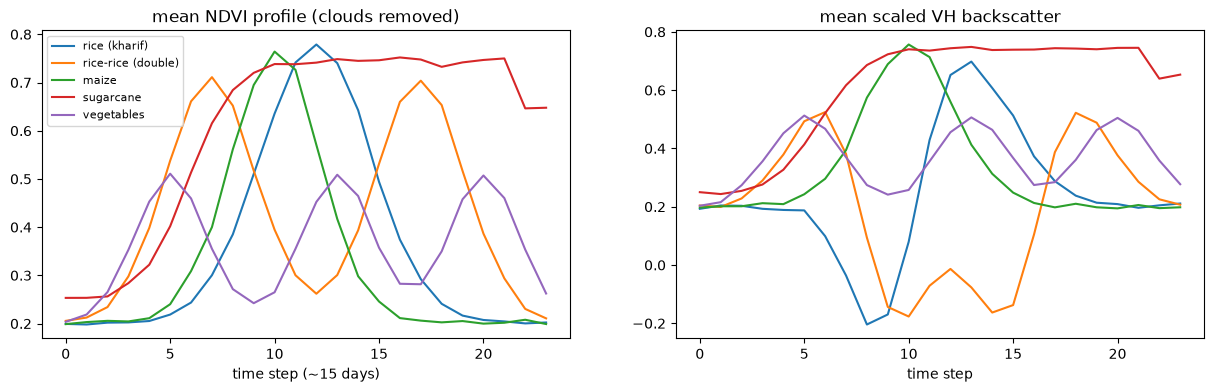

missing optical observations (clouds): 30%


In [5]:
CROPS = ["rice (kharif)", "rice-rice (double)", "maize", "sugarcane", "vegetables"]
def crop_series(kind, r, T=24):
    t = np.arange(T)
    def bump(c, w, h): return h * np.exp(-0.5 * ((t - c) / w) ** 2)
    s = r.normal(0, 0.8)                                                    # field-specific sowing shift (time steps)
    if kind == 0: ndvi = 0.2 + bump(12 + s, 2.5, 0.6)
    elif kind == 1: ndvi = 0.2 + bump(7 + s, 2.0, 0.55) + bump(17 + s, 2.0, 0.55)
    elif kind == 2: ndvi = 0.2 + bump(10 + s, 2.0, 0.6)
    elif kind == 3: ndvi = 0.25 + 0.5 / (1 + np.exp(-(t - 6 - s))) - 0.1 * (t > 21)
    else: ndvi = 0.2 + bump(5 + s, 1.5, 0.35) + bump(13 + s, 1.5, 0.35) + bump(20 + s, 1.5, 0.35)
    ndvi = ndvi * r.uniform(0.85, 1.15) + r.normal(0, 0.03, T)
    flooded = (kind in (0, 1)) * (bump(9 + s, 1.5, 1.0) + (kind == 1) * bump(15 + s, 1.5, 1.0))   # paddy flooding lowers VH
    vh = -18 + 8 * ndvi - 6 * flooded + r.normal(0, 0.8, T)
    return np.c_[ndvi, (vh + 18) / 8].astype(np.float32)

def make_crops(n_per, seed, cloud_frac=0.3):
    r = np.random.default_rng(seed); X, y = [], []
    for k in range(5):
        for _ in range(n_per):
            s_ = crop_series(k, r); cloud = r.random(24) < cloud_frac
            s_[cloud, 0] = np.nan; X.append(s_); y.append(k)
    return np.stack(X), np.array(y)

X_tr, y_tr = make_crops(200, 1); X_va, y_va = make_crops(60, 2); X_te, y_te = make_crops(150, 3)
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for k, c in enumerate(CROPS):
    axes[0].plot(np.nanmean(X_tr[y_tr == k, :, 0], 0), label=c); axes[1].plot(X_tr[y_tr == k, :, 1].mean(0), label=c)
axes[0].set(title="mean NDVI profile (clouds removed)", xlabel="time step (~15 days)"); axes[1].set(title="mean scaled VH backscatter", xlabel="time step"); axes[0].legend(fontsize=8); plt.show()
print(f"missing optical observations (clouds): {np.isnan(X_tr[..., 0]).mean():.0%}")

### Handling cloud gaps
Options: (1) interpolate gaps before modelling; (2) feed a **mask** channel (1 = observed) so the network knows which values are real. We do both: linear interpolation + mask.

In [6]:
def prepare(X):
    X = X.copy(); mask = (~np.isnan(X[..., 0])).astype(np.float32)
    for i in range(len(X)):
        v = X[i, :, 0]; ok = ~np.isnan(v); X[i, :, 0] = np.interp(np.arange(24), np.flatnonzero(ok), v[ok]) if ok.any() else 0.3
    return np.concatenate([X, mask[..., None]], -1)

P_tr, P_va, P_te = prepare(X_tr), prepare(X_va), prepare(X_te)

class CropLSTM(nn.Module):
    def __init__(self, n_in=3, n_hidden=64, n_out=5, cell="lstm", bidirectional=False, layers=2):
        super().__init__()
        rnn_cls = nn.LSTM if cell == "lstm" else nn.GRU
        self.rnn = rnn_cls(n_in, n_hidden, num_layers=layers, batch_first=True, dropout=0.2, bidirectional=bidirectional)
        self.out = nn.Linear(n_hidden * (2 if bidirectional else 1), n_out)
    def forward(self, x):
        o, _ = self.rnn(x); return self.out(o.mean(1))        # average over time (more robust than only the last step)

def fit_eval(model, epochs=40, lr=2e-3):
    torch.manual_seed(0)
    dl = DataLoader(TensorDataset(torch.tensor(P_tr), torch.tensor(y_tr)), batch_size=64, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4); best, best_state = 0, None
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad(); F.cross_entropy(model(xb), yb).backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad(): va = (model(torch.tensor(P_va)).argmax(1).numpy() == y_va).mean()
        if va >= best: best, best_state = va, copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad(): return (model(torch.tensor(P_te)).argmax(1).numpy() == y_te).mean()

res = {"LSTM": fit_eval(CropLSTM(cell="lstm")), "GRU": fit_eval(CropLSTM(cell="gru")), "Bidirectional LSTM": fit_eval(CropLSTM(bidirectional=True))}
from sklearn.ensemble import RandomForestClassifier
res["Random Forest on the 72 flattened values"] = RandomForestClassifier(500, random_state=0, n_jobs=-1).fit(P_tr.reshape(len(P_tr), -1), y_tr).score(P_te.reshape(len(P_te), -1), y_te)
pd.Series(res, name="test accuracy").round(3)

LSTM                                        0.997
GRU                                         0.999
Bidirectional LSTM                          0.999
Random Forest on the 72 flattened values    0.997
Name: test accuracy, dtype: float64

Random Forest on the stacked time steps is a strong, standard baseline for crop mapping; deep temporal models shine with more data, irregular sampling and when **phenological shifts** (sowing dates vary) matter. Project 2 (Days 92-93) studies this properly with spatial validation.

## **5. Forecasting With an LSTM**
Predict the next value of a series from a window of the previous 30 values (sequence-to-one regression).

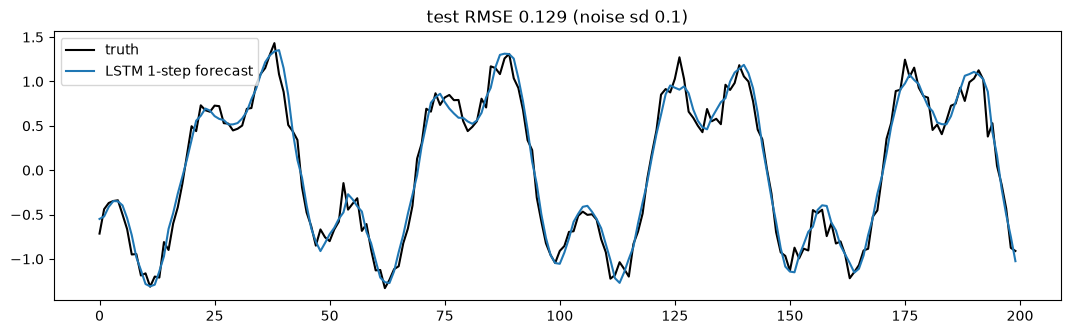

In [7]:
t = np.arange(2000); series = np.sin(2 * np.pi * t / 50) + 0.5 * np.sin(2 * np.pi * t / 17) + rng.normal(0, 0.1, 2000)
W = 30
Xw = np.stack([series[i:i + W] for i in range(len(series) - W)])[..., None].astype(np.float32); yw = series[W:].astype(np.float32)
cut = 1500
class Forecaster(nn.Module):
    def __init__(self): super().__init__(); self.lstm = nn.LSTM(1, 32, batch_first=True); self.out = nn.Linear(32, 1)
    def forward(self, x): o, _ = self.lstm(x); return self.out(o[:, -1]).squeeze(-1)
fm = Forecaster(); opt = torch.optim.Adam(fm.parameters(), 3e-3)
dl = DataLoader(TensorDataset(torch.tensor(Xw[:cut]), torch.tensor(yw[:cut])), batch_size=64, shuffle=True)
for ep in range(15):
    for xb, yb in dl: opt.zero_grad(); F.mse_loss(fm(xb), yb).backward(); opt.step()
with torch.no_grad(): pred = fm(torch.tensor(Xw[cut:])).numpy()
plt.figure(figsize=(13, 3.5)); plt.plot(yw[cut:cut + 200], "k", label="truth"); plt.plot(pred[:200], label="LSTM 1-step forecast")
plt.legend(); plt.title(f"test RMSE {np.sqrt(np.mean((pred - yw[cut:]) ** 2)):.3f} (noise sd 0.1)"); plt.show()

# **Part 2: Going Deeper**

### Temporal convolutions: a fast alternative
1-D convolutions over time (TempCNN, Pelletier et al., 2019) are parallel (no sequential loop), easy to train, and very strong for satellite time series classification.

In [8]:
class TempCNN(nn.Module):
    def __init__(self, n_in=3, n_out=5, h=64):
        super().__init__()
        self.net = nn.Sequential(nn.Conv1d(n_in, h, 5, padding=2), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Conv1d(h, h, 5, padding=2), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Conv1d(h, h, 5, padding=2), nn.BatchNorm1d(h), nn.ReLU(), nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(h, n_out))
    def forward(self, x): return self.net(x.transpose(1, 2))           # (batch, time, features) -> (batch, channels, time)
t0 = time.perf_counter(); acc_tc = fit_eval(TempCNN()); print(f"TempCNN test accuracy {acc_tc:.3f} ({time.perf_counter() - t0:.0f}s)")

TempCNN test accuracy 1.000 (5s)


### Variable-length sequences: packing
When sequences have different lengths (e.g. different numbers of cloud-free dates), pad them and use `pack_padded_sequence` so the RNN ignores the padding.

In [9]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
seqs = [torch.randn(L, 2) for L in [10, 6, 3]]; lengths = torch.tensor([10, 6, 3])
padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True)
packed = pack_padded_sequence(padded, lengths, batch_first=True, enforce_sorted=False)
out, (h_n, c_n) = nn.LSTM(2, 4, batch_first=True)(packed)
print("padded batch:", tuple(padded.shape), "| final hidden state per sequence (uses true lengths):", tuple(h_n.shape))

padded batch: (3, 10, 2) | final hidden state per sequence (uses true lengths): (1, 3, 4)


## **Practice Problems**
1. Train the vanilla RNN on the memory task with T = 60 **without** gradient clipping (clip = 1e9). What happens?
2. Remove the mask channel from the crop data. Does accuracy change?
3. Increase the cloud fraction to 0.6. Which model (LSTM, TempCNN, RF) is most robust?
4. *(Advanced)* Implement an LSTM cell from scratch with the gate equations and check it against `nn.LSTMCell`.

In [10]:
# Solution 1
Xm_, ym_ = memory_task(2000, 60, rng); Xvm_, yvm_ = memory_task(500, 60, rng)
print("RNN without clipping, T=60:", round(train_seq(SeqClassifier("rnn"), Xm_, ym_, Xvm_, yvm_, epochs=15, clip=1e9), 3))
# Solution 2
P_tr2, P_va2, P_te2 = P_tr[..., :2], P_va[..., :2], P_te[..., :2]
_bk = (P_tr, P_va, P_te); P_tr, P_va, P_te = P_tr2, P_va2, P_te2
print("LSTM without mask channel:", round(fit_eval(CropLSTM(n_in=2)), 3)); P_tr, P_va, P_te = _bk
# Solution 3
X_tr6, _ = make_crops(200, 1, 0.6); X_va6, _ = make_crops(60, 2, 0.6); X_te6, _ = make_crops(150, 3, 0.6)
_bk = (P_tr, P_va, P_te); P_tr, P_va, P_te = prepare(X_tr6), prepare(X_va6), prepare(X_te6)
print("60% clouds: LSTM", round(fit_eval(CropLSTM()), 3), "| TempCNN", round(fit_eval(TempCNN()), 3),
      "| RF", round(RandomForestClassifier(500, random_state=0, n_jobs=-1).fit(P_tr.reshape(len(P_tr), -1), y_tr).score(P_te.reshape(len(P_te), -1), y_te), 3))
P_tr, P_va, P_te = _bk
# Solution 4
class LSTMCellScratch(nn.Module):
    def __init__(self, n_in, n_h):
        super().__init__(); self.W = nn.Linear(n_in, 4 * n_h); self.U = nn.Linear(n_h, 4 * n_h, bias=False)
    def forward(self, x, h, c):
        i, f, g, o = (self.W(x) + self.U(h)).chunk(4, 1)                      # PyTorch gate order: input, forget, cell, output
        c = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g); h = torch.sigmoid(o) * torch.tanh(c); return h, c
cell, ref_cell = LSTMCellScratch(3, 5), nn.LSTMCell(3, 5)
with torch.no_grad():
    ref_cell.weight_ih.copy_(cell.W.weight); ref_cell.bias_ih.copy_(cell.W.bias); ref_cell.weight_hh.copy_(cell.U.weight); ref_cell.bias_hh.zero_()
x0, h0, c0 = torch.randn(2, 3), torch.randn(2, 5), torch.randn(2, 5)
print("scratch LSTM cell == nn.LSTMCell:", all(torch.allclose(a, b, atol=1e-6) for a, b in zip(cell(x0, h0, c0), ref_cell(x0, (h0, c0)))))

RNN without clipping, T=60: 0.714


LSTM without mask channel: 1.0


60% clouds: LSTM 1.0 | TempCNN 1.0 | RF 0.992
scratch LSTM cell == nn.LSTMCell: True


## **Key References**
- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735-1780.
- Cho, K. et al. (2014). Learning phrase representations using RNN encoder-decoder for statistical machine translation. *EMNLP 2014* (GRU).
- Bengio, Y., Simard, P., & Frasconi, P. (1994). Learning long-term dependencies with gradient descent is difficult. *IEEE Transactions on Neural Networks*, 5(2), 157-166.
- Russwurm, M., & Korner, M. (2017). Temporal vegetation modelling using long short-term memory networks for crop identification from medium-resolution multi-spectral satellite images. *CVPR Workshops 2017*.
- Pelletier, C., Webb, G. I., & Petitjean, F. (2019). Temporal convolutional neural network for the classification of satellite image time series. *Remote Sensing*, 11(5), 523.
- Pascanu, R., Mikolov, T., & Bengio, Y. (2013). On the difficulty of training recurrent neural networks. *ICML 2013*.